#### ELR Volume Surveillance

#### Objective

Analyze Electronic Laboratory Reporting (ELR) message volume across facilities and districts.

This analysis provides foundational reporting metrics that can be used later for timeliness monitoring and anomaly detection.

In [5]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.Preprocess import load_data, prepare_elr
from src.volume_analysis import daily_volume, facility_volume, district_volume
from src.utils import save_fig


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [6]:
elr, facility, district, lab = load_data()

df = prepare_elr(
    elr,
    facility,
    district
)

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 11238
Columns: 19


,msg_control_id,facility_id_elr,facility_name_elr,clia_id,county_elr,patient_race,patient_ethnicity,patient_phone,patient_address,collection_date,created_date,insert_date,facility_id_fac,facility_name_fac,county_fac,district,facility_name,county,district_dist
0,MSG000001,F001,Northside Medical Center,11D0001111,Adams,Black,Not Hispanic,555-314-5426,8422 Main St,2024-12-30,2025-01-04,2025-01-04,F001,Northside Medical Center,Adams,North,Northside Medical Center,Adams,North
1,MSG000002,F001,Northside Medical Center,11D0001111,Adams,NaN,Hispanic,555-376-2184,6496 Main St,2024-12-31,2025-01-03,2025-01-03,F001,Northside Medical Center,Adams,North,Northside Medical Center,Adams,North
2,MSG000003,F001,Northside Medical Center,11D0001111,Adams,Black,Hispanic,555-575-3747,289 Main St,2025-01-01,2025-01-03,2025-01-03,F001,Northside Medical Center,Adams,North,Northside Medical Center,Adams,North
3,MSG000004,F001,Northside Medical Center,11D0001111,Adams,Black,Not Hispanic,555-230-4556,NaN,2024-12-30,2025-01-02,2025-01-02,F001,Northside Medical Center,Adams,North,Northside Medical Center,Adams,North
4,MSG000005,F001,Northside Medical Center,11D0001111,Adams,Other,Not Hispanic,555-664-8041,5586 Main St,2024-12-29,2025-01-05,2025-01-05,F001,Northside Medical Center,Adams,North,Northside Medical Center,Adams,North


##### Daily ELR Message Volume

Count the number of ELR messages received each day.

In [7]:
daily = daily_volume(df)

daily.head()

,insert_date,message_count
0,2024-12-28,1
1,2024-12-29,12
2,2024-12-30,18
3,2024-12-31,44
4,2025-01-01,61


In [11]:
daily.head()

,insert_date,message_count
0,2024-12-28,1
1,2024-12-29,12
2,2024-12-30,18
3,2024-12-31,44
4,2025-01-01,61


In [12]:
print(daily.columns.tolist())

['insert_date', 'message_count']


##### Daily Volume Plot

Saved figure → c:\Users\sanhi\Downloads\elr_surveillance_analysis\outputs\figures\daily_elr_volume.png


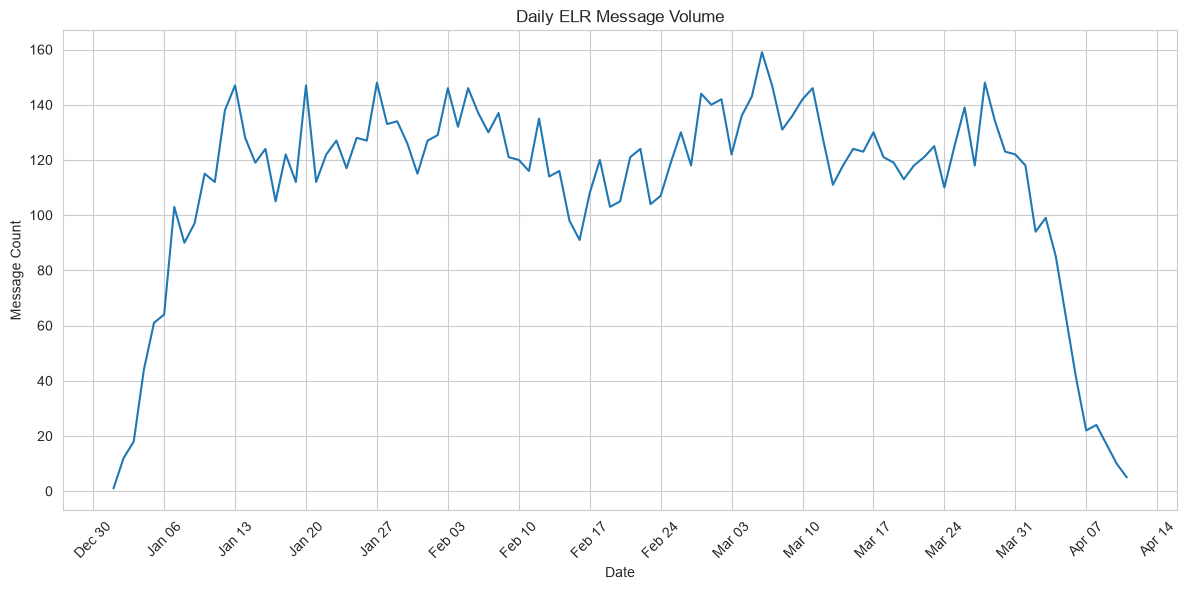

In [14]:
import matplotlib.dates as mdates

plt.figure(figsize=(12,6))

sns.lineplot(
    data=daily,
    x="insert_date",   # or "date"
    y="message_count"
)

plt.title("Daily ELR Message Volume")
plt.xlabel("Date")
plt.ylabel("Message Count")

# Show fewer dates
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=45)

plt.tight_layout()

save_fig("daily_elr_volume")

plt.show()

##### Facility-Level Reporting Volume

Identify facilities contributing the highest number of ELR messages.

In [15]:
fac = facility_volume(df)

fac.head()

,facility_name,clia_id,message_count
0,Central County Hospital,22D0002222,2260
1,Northside Medical Center,11D0001111,2219
2,Riverbend Clinic,44D0004444,2231
3,South Regional Hospital,55D0005555,2441
4,Valley Diagnostic Lab,33D0003333,2087


#### Top Facilities

Saved figure → c:\Users\sanhi\Downloads\elr_surveillance_analysis\outputs\figures\top_reporting_facilities.png


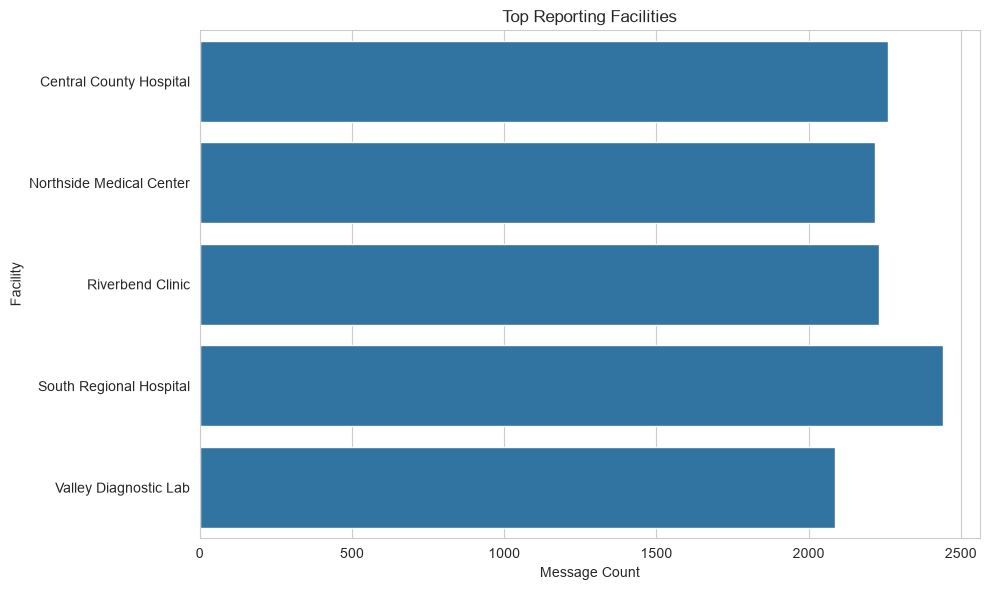

In [16]:
top_fac = fac.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_fac,
    y="facility_name",
    x="message_count"
)

plt.title("Top Reporting Facilities")
plt.xlabel("Message Count")
plt.ylabel("Facility")

plt.tight_layout()

save_fig("top_reporting_facilities")

plt.show()

#### District-Level Reporting Volume

Aggregate ELR reporting activity by district.

In [17]:
dist = district_volume(df)

dist

,district,message_count
0,Central,4318
1,North,4479
2,South,2441


#### District Plot

Saved figure → c:\Users\sanhi\Downloads\elr_surveillance_analysis\outputs\figures\district_volume.png


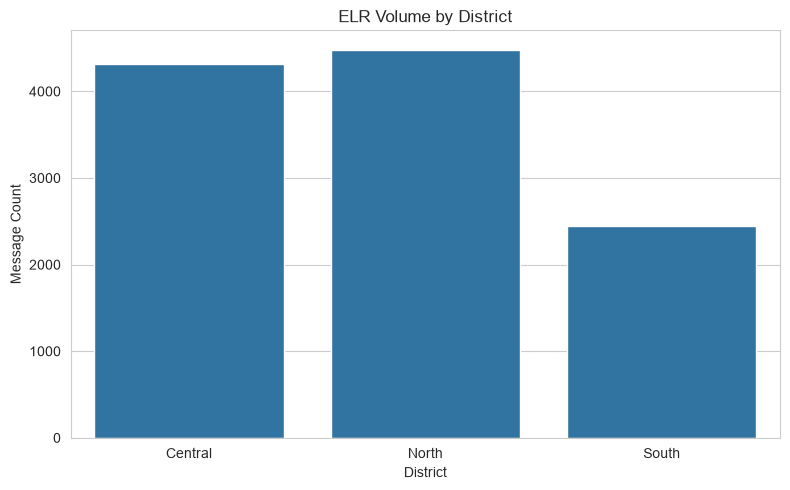

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=dist,
    x="district",
    y="message_count"
)

plt.title("ELR Volume by District")
plt.xlabel("District")
plt.ylabel("Message Count")

plt.tight_layout()

save_fig("district_volume")

plt.show()

#### Weekly ELR Volume Trend

Review reporting activity at the weekly level to identify broader trends.

In [19]:
df["week"] = pd.to_datetime(
    df["insert_date"]
).dt.isocalendar().week

weekly = (
    df.groupby("week")["msg_control_id"]
    .count()
    .reset_index()
)

weekly.columns = [
    "week",
    "message_count"
]

weekly.head()

,week,message_count
0,1,477
1,2,883
2,3,847
3,4,913
4,5,932


#### Weekly plot 

Saved figure → c:\Users\sanhi\Downloads\elr_surveillance_analysis\outputs\figures\weekly_volume_trend.png


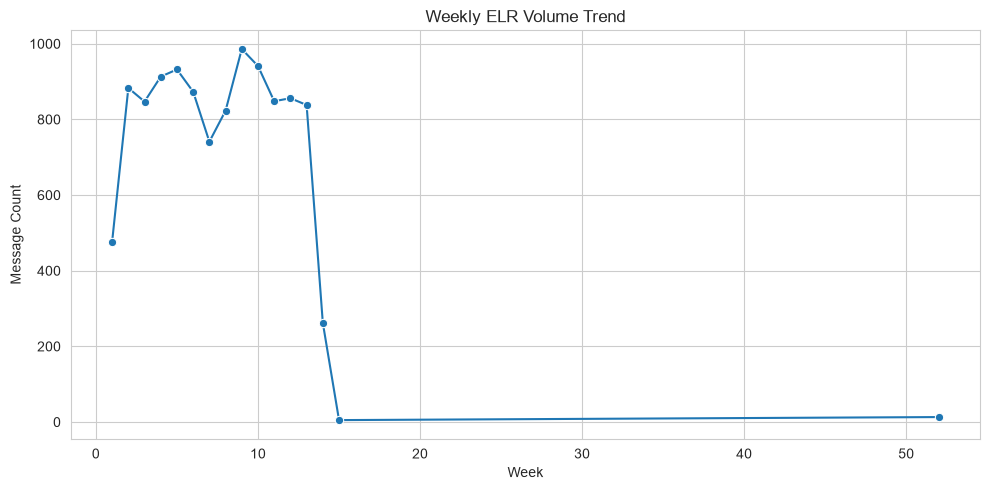

In [20]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=weekly,
    x="week",
    y="message_count",
    marker="o"
)

plt.title("Weekly ELR Volume Trend")
plt.xlabel("Week")
plt.ylabel("Message Count")

plt.tight_layout()

save_fig("weekly_volume_trend")

plt.show()

##### Key Findings

### Daily Reporting Volume

- ELR reporting volume remained relatively stable throughout the reporting period.
- Daily message counts generally ranged between 100 and 150 messages.

### Facility Reporting

- South Regional Hospital generated the highest reporting volume.
- Reporting activity was distributed across multiple facilities rather than concentrated in a single source.

### District Reporting

- North and Central districts contributed the highest overall reporting volume.
- South district reported fewer messages than the other districts.

### Surveillance Value

These baseline reporting patterns provide a foundation for identifying future reporting anomalies, including facility reporting interruptions and unusually large reporting surges.